# Laboratorio 5: Clasificación de Imágenes con Redes Neuronales Densas en PyTorch

### Objetivos y Características Principales:
1. **Adaptabilidad Total:**
   - Parámetros de configuración centralizados (`IMG_SIZE`, `BATCH_SIZE`, `EPOCHS`).
   - Redimensionamiento automático mediante `transforms.Resize()` para admitir imágenes de cualquier resolución original.
   - Cálculo automático de la dimensión de entrada aplanada ($input\_dim = C \times H \times W$) y del número de clases ($num\_classes$).
2. **Visualización Completa de TODAS las Clases:**
   - Se genera una cuadrícula donde se visualiza **una muestra representativa de cada una de las clases del dataset** (en CIFAR-100 se muestran las 100 clases completas en una matriz de $10 \times 10$).
3. **Comparación de 2 Modelos Densos (Sin Redes Convolucionales):**
   - **Modelo 1: Red Neuronal Densa Base (MLP):** Perceptrón multicapa con 1 capa oculta y activación no lineal ReLU.
   - **Modelo 2: Red Neuronal Densa Optimizada:** Perceptrón multicapa profundo integrando la receta de los **Cuadernillos 06 y 07** (`BatchNorm1d`, `Dropout`, `StepLR Scheduler`, regularización $L_2$ `weight_decay` y `Early Stopping`).
4. **Carga Eficiente de Datos:**
   - Uso de `ImageFolder` y `DataLoader(..., shuffle=True)` para carga perezosa y barajado dinámico por época, sin saturar la memoria RAM.

In [11]:
# Esta celda importa las librerías necesarias para visión artificial, tensores y evaluación en PyTorch.
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Objetos de PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# Métricas del Cuadernillo 08
from sklearn.metrics import accuracy_score, confusion_matrix, top_k_accuracy_score

# Configuración de semilla para reproducibilidad científica
def set_seed(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        try:
            torch.cuda.manual_seed_all(seed)
        except Exception:
            pass
    np.random.seed(seed)

set_seed(42)

# Detección del acelerador de hardware (GPU CUDA o CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo detectado: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'Dispositivo en uso: {device}')

Dispositivo detectado: NVIDIA GeForce RTX 4050 Laptop GPU
Dispositivo en uso: cuda


In [12]:

# 1. Rutas a las carpetas de entrenamiento y prueba (Estructura: carpeta/clase/imagen.jpg)
TRAIN_DIR = r'E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio5\cifar100\train'
TEST_DIR  = r'E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio5\cifar100\test'

# 2. Tamaño estándar al que se redimensionarán TODAS las imágenes automáticamente
# Esto permite que el código acepte imágenes de 32x32, 64x64, 128x128, etc., sin romper la red.
IMG_SIZE = (32, 32)

# 3. Hiperparámetros de entrenamiento
BATCH_SIZE = 256
EPOCHS = 30
PATIENCE = 3

# 4. Pipeline de transformación con Redimensionamiento Automático
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE), # Redimensiona cualquier imagen al tamaño estándar
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

# 5. Carga diferida con ImageFolder (Sin cargar todo en RAM de golpe)
train_dataset = torchvision.datasets.ImageFolder(root=TRAIN_DIR, transform=transform)
test_dataset  = torchvision.datasets.ImageFolder(root=TEST_DIR, transform=transform)

# 6. Extracción dinámica de propiedades del dataset
clases = train_dataset.classes
num_classes = len(clases)

# Detección automática de dimensiones a partir de una muestra
sample_img, _ = train_dataset[0]
channels, img_h, img_w = sample_img.shape
input_dim = channels * img_h * img_w # Dimensión del vector aplanado de entrada

# Creación de DataLoaders de PyTorch
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print("=" * 70)
print("RESUMEN DEL DATASET CARGADO (DETECCIÓN AUTOMÁTICA):")
print("=" * 70)
print(f" - Número total de clases detectadas:       {num_classes}")
print(f" - Formato de imagen:                      {channels} canales x {img_h} alto x {img_w} ancho")
print(f" - Dimensión total de entrada (input_dim):  {input_dim} características")
print(f" - Muestras de entrenamiento:               {len(train_dataset)} imágenes ({len(train_loader)} batches)")
print(f" - Muestras de prueba (test):               {len(test_dataset)} imágenes ({len(test_loader)} batches)")
print("=" * 70)

RESUMEN DEL DATASET CARGADO (DETECCIÓN AUTOMÁTICA):
 - Número total de clases detectadas:       100
 - Formato de imagen:                      3 canales x 32 alto x 32 ancho
 - Dimensión total de entrada (input_dim):  3072 características
 - Muestras de entrenamiento:               50000 imágenes (196 batches)
 - Muestras de prueba (test):               10000 imágenes (40 batches)


In [13]:
# ==============================================================================
# DESPLIEGUE COMPLETO DE TODAS LAS CLASES DEL DATASET
# ==============================================================================
print(f"Listado de las {num_classes} clases disponibles en el dataset:\n")

# Se organiza dinámicamente en columnas para facilitar su lectura
cols_tabla = 10 if num_classes >= 10 else num_classes
filas_tabla = math.ceil(num_classes / cols_tabla)

lista_formateada = clases + [''] * (filas_tabla * cols_tabla - num_classes)
matriz_clases = np.array(lista_formateada).reshape(filas_tabla, cols_tabla)

df_clases = pd.DataFrame(matriz_clases)
df_clases.columns = [f'C{j}' for j in range(cols_tabla)]
df_clases.index = [f'{i*cols_tabla:02d}-{(i+1)*cols_tabla-1:02d}:' for i in range(filas_tabla)]
print(df_clases.to_string())

Listado de las 100 clases disponibles en el dataset:

              C0             C1         C2            C3         C4       C5           C6          C7            C8         C9
00-09:     apple  aquarium_fish       baby          bear     beaver      bed          bee      beetle       bicycle     bottle
10-19:      bowl            boy     bridge           bus  butterfly    camel          can      castle   caterpillar     cattle
20-29:     chair     chimpanzee      clock         cloud  cockroach    couch         crab   crocodile           cup   dinosaur
30-39:   dolphin       elephant   flatfish        forest        fox     girl      hamster       house      kangaroo   keyboard
40-49:      lamp     lawn_mower    leopard          lion     lizard  lobster          man  maple_tree    motorcycle   mountain
50-59:     mouse       mushroom   oak_tree        orange     orchid    otter    palm_tree        pear  pickup_truck  pine_tree
60-69:     plain          plate      poppy     porcupine 

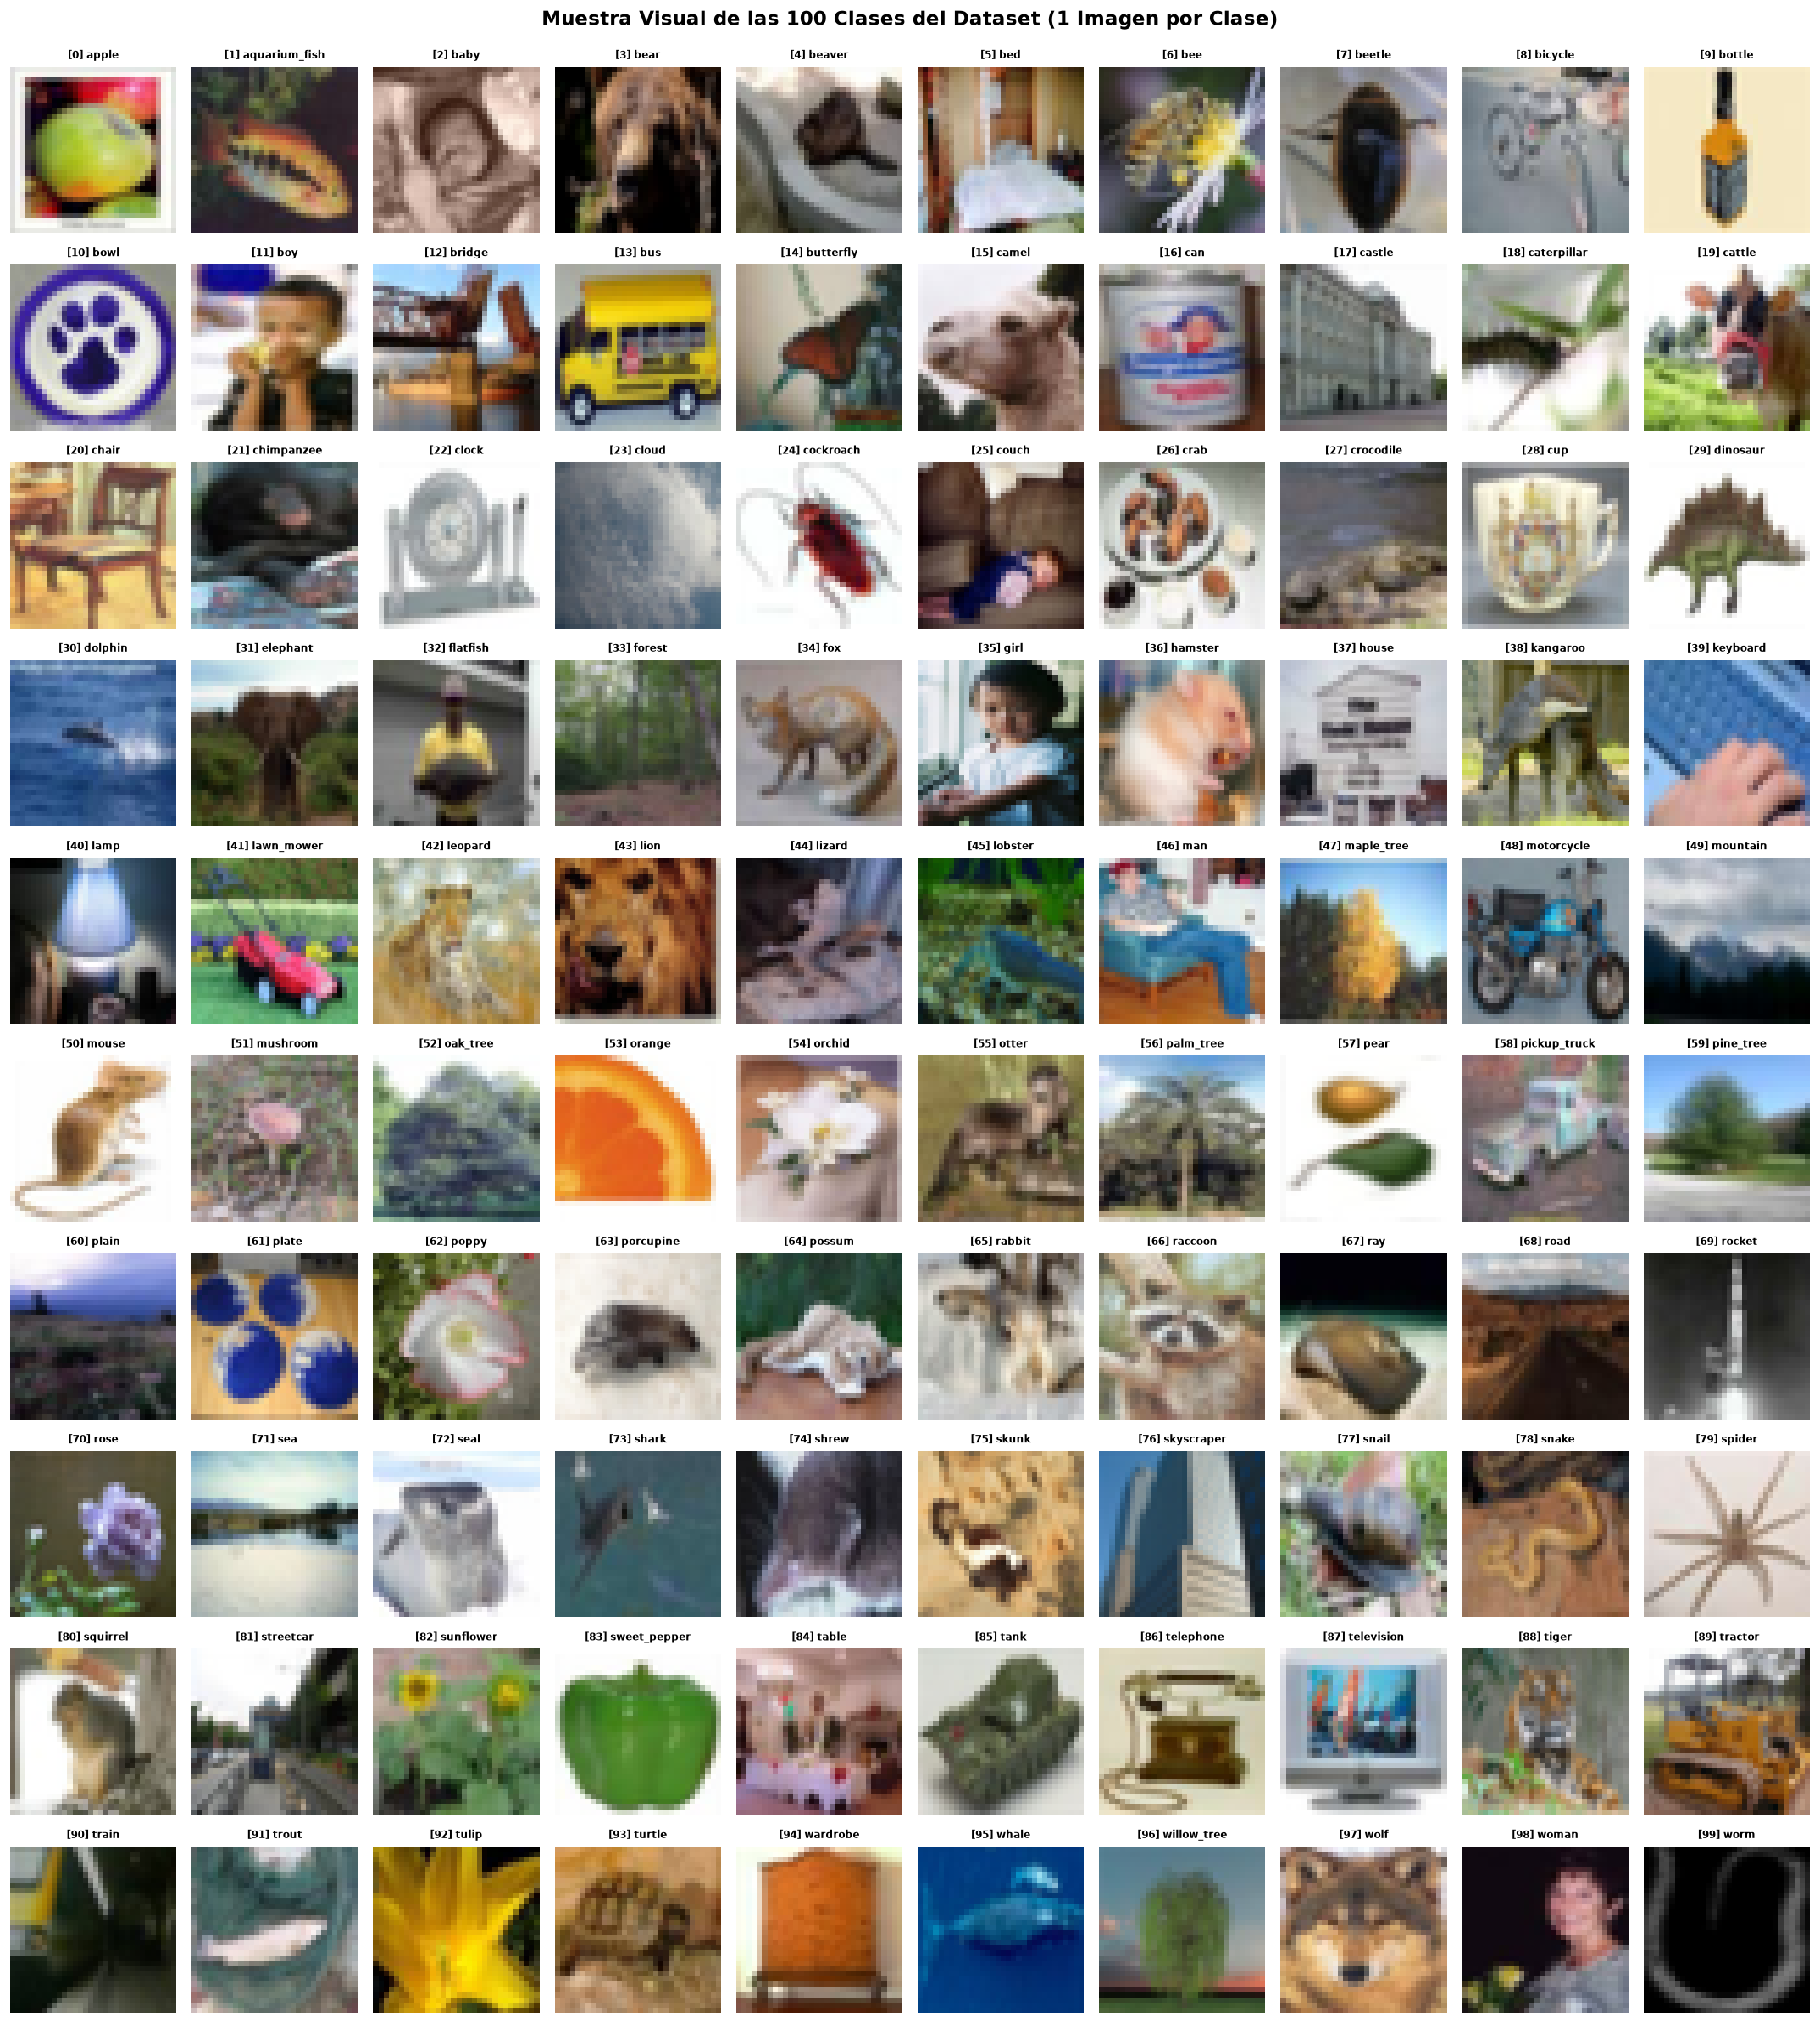

In [14]:
# ==============================================================================
# VISUALIZACIÓN DE TODAS LAS CLASES DEL DATASET (UNA IMAGEN POR CADA CLASE)
# ==============================================================================
def desnormalizar(tensor):
    # Invierte la normalización [-1, 1] al rango visible [0, 1] para matplotlib
    return tensor * 0.5 + 0.5

# Extraemos el primer índice de cada clase usando las etiquetas del dataset
targets_arr = np.array(train_dataset.targets)
indices_por_clase = [np.where(targets_arr == c)[0][0] for c in range(num_classes)]

# Calculamos filas y columnas de la cuadrícula
grid_cols = 10 if num_classes >= 10 else num_classes
grid_rows = math.ceil(num_classes / grid_cols)

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(grid_cols * 1.8, grid_rows * 2.0), dpi=120)
axes = np.array(axes).reshape(-1)

for c in range(num_classes):
    idx = indices_por_clase[c]
    img, lbl = train_dataset[idx]
    img_desnorm = desnormalizar(img).permute(1, 2, 0).cpu().numpy()
    img_desnorm = np.clip(img_desnorm, 0, 1)
    
    axes[c].imshow(img_desnorm)
    axes[c].set_title(f"[{c}] {clases[lbl]}", fontsize=7, fontweight='bold')
    axes[c].axis('off')

# Ocultamos ejes vacíos si la última fila no está llena
for extra in range(num_classes, len(axes)):
    axes[extra].axis('off')

plt.suptitle(f'Muestra Visual de las {num_classes} Clases del Dataset (1 Imagen por Clase)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [15]:

# 1. Comprobación de dimensiones dinámicas
test_input = torch.randn((16, channels, img_h, img_w)).to(device)
test_model_check = nn.Sequential(
    nn.Flatten(),
    nn.Linear(input_dim, num_classes)
).to(device)

test_output = test_model_check(test_input)
print(f"Sanity Check de dimensiones: entrada {test_input.shape} -> salida {test_output.shape}")

# 2. Comprobación del costo teórico inicial (para num_classes equiprobables)
# Valor teórico esperado: -ln(1 / num_classes) = ln(num_classes)
criterion = nn.CrossEntropyLoss()
test_target = torch.randint(0, num_classes, (16,)).to(device)
loss_inicial = criterion(test_output, test_target).item()
loss_teorica = np.log(num_classes)

print(f"Pérdida teórica esperada:  ln({num_classes}) = {loss_teorica:.4f}")
print(f"Pérdida inicial observada: {loss_inicial:.4f}")
print("-> El costo inicial es coherente con una inicialización uniforme de pesos.")

Sanity Check de dimensiones: entrada torch.Size([16, 3, 32, 32]) -> salida torch.Size([16, 100])
Pérdida teórica esperada:  ln(100) = 4.6052
Pérdida inicial observada: 4.9640
-> El costo inicial es coherente con una inicialización uniforme de pesos.


---
## Modelo 1: Red Neuronal Densa Base - MLP (PyTorch con Capa Oculta y ReLU)
Este modelo representa la estructura estándar de un **Perceptrón Multicapa (MLP)** para clasificación:
$$\text{Entrada } (input\_dim) \longrightarrow \text{Linear(256)} \longrightarrow \text{ReLU} \longrightarrow \text{Linear}(num\_classes)$$
- **Aplanado:** Transforma las imágenes multidimensionales a un vector unidimensional de tamaño $input\_dim$.
- **Capa Oculta (256 neuronas):** Introduce combinaciones no lineales de características visuales.
- **Función de Activación ReLU:** $\max(0, z)$, permite que la red aprenda fronteras de decisión no lineales.
- **Optimizador:** Adam con tasa de aprendizaje estándar de $0.001$.

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=100, bias=True)
)
Total de parámetros entrenables: 812,388

=== ENTRENANDO MODELO 1: RED DENSA BASE (MLP) SOBRE 100 CLASES ===
Época 01/30 - Loss: 3.7528 | Val Loss: 3.5681 | Acc: 14.35% | Val Acc: 17.16% [52.7s] (Mejor modelo guardado)
Época 02/30 - Loss: 3.3317 | Val Loss: 3.4107 | Acc: 21.55% | Val Acc: 20.70% [34.2s] (Mejor modelo guardado)
Época 03/30 - Loss: 3.1360 | Val Loss: 3.3365 | Acc: 25.08% | Val Acc: 22.46% [34.1s] (Mejor modelo guardado)
Época 04/30 - Loss: 2.9894 | Val Loss: 3.3359 | Acc: 27.81% | Val Acc: 22.05% [33.3s] 
Época 05/30 - Loss: 2.8577 | Val Loss: 3.2981 | Acc: 30.36% | Val Acc: 23.26% [32.8s] (Mejor modelo guardado)
Época 06/30 - Loss: 2.7387 | Val Loss: 3.2886 | Acc: 32.87% | Val Acc: 24.20% [33.8s] (Mejor modelo guardado)
Época 07/30 - Loss: 2.6475 | Val Loss: 3.2976 | Acc: 34.75% | Val

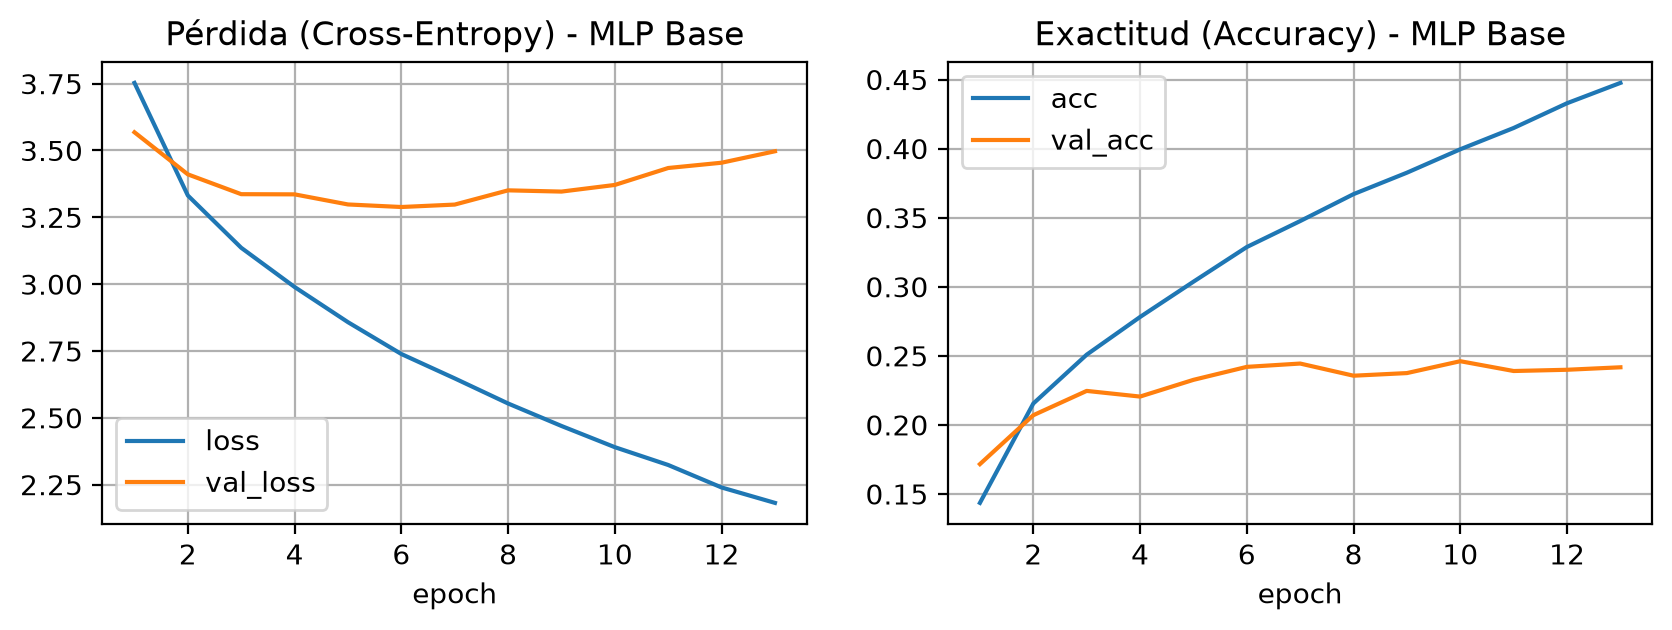

In [16]:
# ==============================================================================
# MODELO 1: RED NEURONAL DENSA BASE (MLP)
# ==============================================================================
model_mlp_base = nn.Sequential(
    nn.Flatten(),
    nn.Linear(input_dim, 256),
    nn.ReLU(),
    nn.Linear(256, num_classes)
).to(device)

print(model_mlp_base)
num_params_base = sum(p.numel() for p in model_mlp_base.parameters() if p.requires_grad)
print(f"Total de parámetros entrenables: {num_params_base:,}")

optimizer_mlp_base = torch.optim.Adam(model_mlp_base.parameters(), lr=0.001)
BEST_MODEL_MLP_BASE_PATH = 'best_model_mlp_base_adaptable.pt'

patience_counter = 0
best_val_acc_mlp_base = 0.0

hist_mlp_base = {'epoch': [], 'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}

print(f"\n=== ENTRENANDO MODELO 1: RED DENSA BASE (MLP) SOBRE {num_classes} CLASES ===")
for epoch in range(1, EPOCHS + 1):
    model_mlp_base.train()
    batch_losses, batch_correct, batch_total = [], 0, 0
    t0 = time.time()

    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)

        optimizer_mlp_base.zero_grad()
        out = model_mlp_base(x_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer_mlp_base.step()

        batch_losses.append(loss.item())
        batch_correct += (out.argmax(1) == y_b).sum().item()
        batch_total += y_b.size(0)

    train_loss = float(np.mean(batch_losses))
    train_acc = batch_correct / batch_total

    # Validación en Test
    model_mlp_base.eval()
    val_losses, val_correct, val_total = [], 0, 0
    with torch.no_grad():
        for x_val, y_val in test_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            val_out = model_mlp_base(x_val)
            v_loss = criterion(val_out, y_val)
            val_losses.append(v_loss.item())
            val_correct += (val_out.argmax(1) == y_val).sum().item()
            val_total += y_val.size(0)

    val_loss = float(np.mean(val_losses))
    val_acc = val_correct / val_total

    hist_mlp_base['epoch'].append(epoch)
    hist_mlp_base['loss'].append(train_loss)
    hist_mlp_base['val_loss'].append(val_loss)
    hist_mlp_base['acc'].append(train_acc)
    hist_mlp_base['val_acc'].append(val_acc)

    # Checkpoint y Early Stopping
    if val_acc > best_val_acc_mlp_base:
        best_val_acc_mlp_base = val_acc
        torch.save(model_mlp_base.state_dict(), BEST_MODEL_MLP_BASE_PATH)
        patience_counter = 0
        guardado = '(Mejor modelo guardado)'
    else:
        patience_counter += 1
        guardado = ''

    print(f"Época {epoch:02d}/{EPOCHS} - Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}% [{time.time()-t0:.1f}s] {guardado}")

    if patience_counter >= PATIENCE:
        print(f"\n--> Early Stopping en Época {epoch}: detención automática.")
        break

# Cargar el mejor modelo guardado
model_mlp_base.load_state_dict(torch.load(BEST_MODEL_MLP_BASE_PATH, map_location=device, weights_only=True))
model_mlp_base.eval()

# Evaluación completa en Test
all_preds_base, all_targets_base = [], []
with torch.no_grad():
    for x_val, y_val in test_loader:
        x_val = x_val.to(device)
        out = model_mlp_base(x_val)
        all_preds_base.append(out.cpu().numpy())
        all_targets_base.append(y_val.numpy())

all_preds_base = np.concatenate(all_preds_base, axis=0)
all_targets_base = np.concatenate(all_targets_base, axis=0)
pred_labels_base = all_preds_base.argmax(axis=1)

acc_top1_base = accuracy_score(all_targets_base, pred_labels_base)
acc_top5_base = top_k_accuracy_score(all_targets_base, all_preds_base, k=min(5, num_classes), labels=list(range(num_classes)))

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('\n------------------ RESULTADOS EN TEST (MODELO 1: MLP BASE) ------------------')
print(f'Exactitud Top-1 (Accuracy): {acc_top1_base * 100:.2f}% (Azar = {100/num_classes:.2f}%)')
print(f'Exactitud Top-5 (Accuracy): {acc_top5_base * 100:.2f}%')
print(f'Pérdida en Test (Loss):     {hist_mlp_base["val_loss"][-1]:.4f}')
print('-----------------------------------------------------------------------------\n')

# Gráfica de evaluación del Cuadernillo 05
hist = hist_mlp_base
fig = plt.figure(dpi=200, figsize=(10, 3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax.set_title('Pérdida (Cross-Entropy) - MLP Base')
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
ax.set_title('Exactitud (Accuracy) - MLP Base')
plt.show()

---
## Modelo 2: Red Neuronal Densa Optimizada (La Receta Profesional de los Cuadernillos 06 y 07)
Integra el conjunto completo de técnicas de optimización y regularización recomendadas en los **Cuadernillos 06 (Optimización) y 07 (Receta de Entrenamiento)** para maximizar la generalización:
$$\text{Linear}(input\_dim, 512) \rightarrow \mathbf{BatchNorm1d}(512) \rightarrow \text{ReLU} \rightarrow \mathbf{Dropout}(0.2)$$
$$\longrightarrow \text{Linear}(512, 256) \rightarrow \mathbf{BatchNorm1d}(256) \rightarrow \text{ReLU} \rightarrow \mathbf{Dropout}(0.2) \longrightarrow \text{Linear}(256, num\_classes)$$

### Mejoras aplicadas:
1. **Normalización de Capas (`nn.BatchNorm1d`):** Estabiliza la distribución de las activaciones internas y acelera la convergencia.
2. **Regularización Estocástica (`nn.Dropout(p=0.2)`):** Desactiva aleatoriamente el 20% de las neuronas en cada batch para evitar co-adaptación y sobreajuste.
3. **Planificador de Tasa de Aprendizaje (`torch.optim.lr_scheduler.StepLR`):** Reduce la tasa de aprendizaje progresivamente ($	imes 0.5$ cada 3 épocas) para asentar los pesos finamente sobre el mínimo.
4. **Decaimiento de Pesos ($L_2$ Weight Decay = 1e-4):** Penaliza pesos excesivos en el optimizador Adam.

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=512, bias=True)
  (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.2, inplace=False)
  (5): Linear(in_features=512, out_features=256, bias=True)
  (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): ReLU()
  (8): Dropout(p=0.2, inplace=False)
  (9): Linear(in_features=256, out_features=100, bias=True)
)
Total de parámetros entrenables: 1,731,940

=== ENTRENANDO MODELO 2: RED DENSA OPTIMIZADA SOBRE 100 CLASES ===
Época 01/30 - Loss: 3.8329 | Val Loss: 3.5223 | Acc: 12.32% | Val Acc: 17.36% | lr: 0.00100 [35.4s] (Mejor modelo guardado)
Época 02/30 - Loss: 3.4310 | Val Loss: 3.3199 | Acc: 18.26% | Val Acc: 21.32% | lr: 0.00100 [36.0s] (Mejor modelo guardado)
Época 03/30 - Loss: 3.2670 | Val Loss: 3.2181 | Acc: 21.01% | Val Acc: 23.08% | lr: 0.00100 [36.6s] (Mejor modelo guardado)
Époc

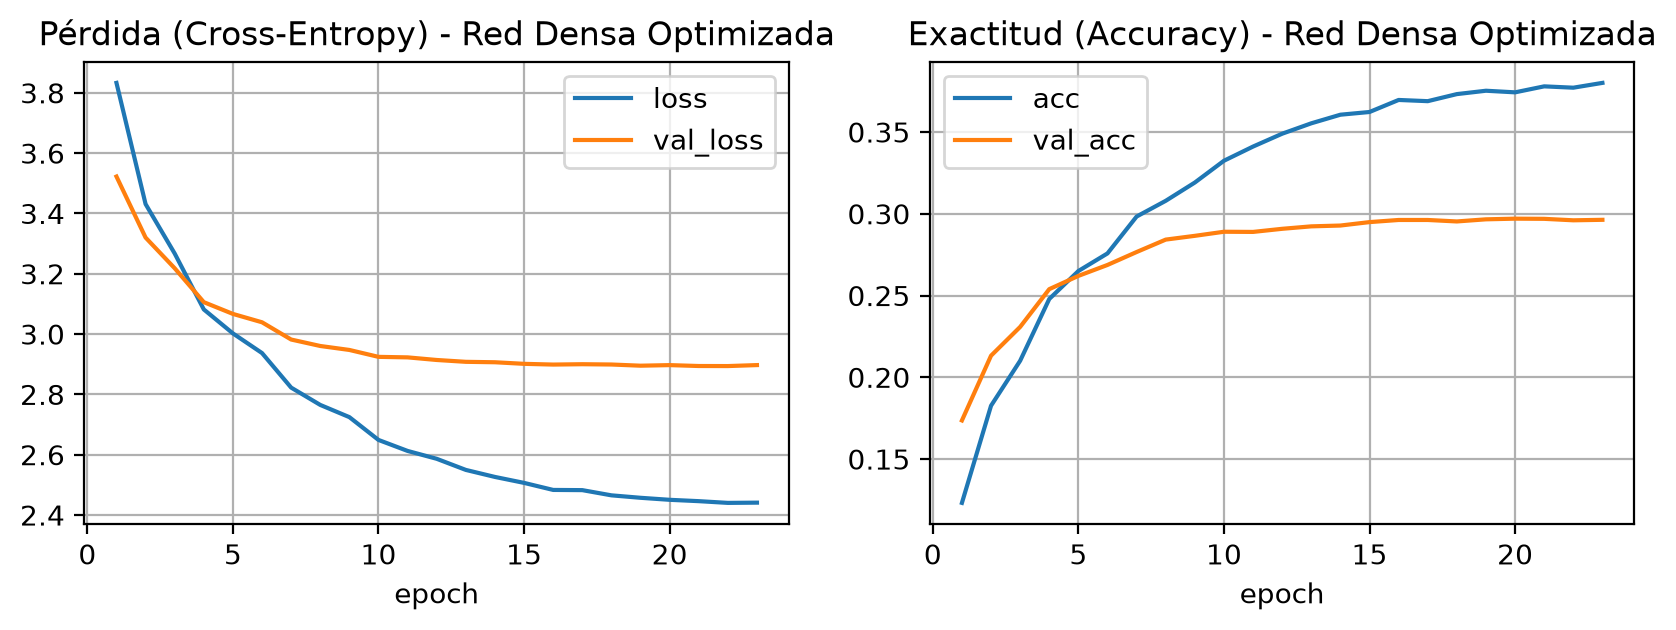

In [17]:
# ==============================================================================
# MODELO 2: RED NEURONAL DENSA OPTIMIZADA (RECETA CUADERNILLOS 06 Y 07)
# ==============================================================================
model_opt = nn.Sequential(
    nn.Flatten(),
    nn.Linear(input_dim, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(p=0.2),

    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(p=0.2),

    nn.Linear(256, num_classes)
).to(device)

print(model_opt)
num_params_opt = sum(p.numel() for p in model_opt.parameters() if p.requires_grad)
print(f"Total de parámetros entrenables: {num_params_opt:,}")

optimizer_opt = torch.optim.Adam(model_opt.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer_opt, step_size=3, gamma=0.5)
BEST_MODEL_OPT_PATH = 'best_model_opt_adaptable.pt'

patience_counter = 0
best_val_acc_opt = 0.0

hist_opt = {'epoch': [], 'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}

print(f"\n=== ENTRENANDO MODELO 2: RED DENSA OPTIMIZADA SOBRE {num_classes} CLASES ===")
for epoch in range(1, EPOCHS + 1):
    model_opt.train()
    batch_losses, batch_correct, batch_total = [], 0, 0
    t0 = time.time()

    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)

        optimizer_opt.zero_grad()
        out = model_opt(x_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer_opt.step()

        batch_losses.append(loss.item())
        batch_correct += (out.argmax(1) == y_b).sum().item()
        batch_total += y_b.size(0)

    train_loss = float(np.mean(batch_losses))
    train_acc = batch_correct / batch_total

    # Ajuste de tasa de aprendizaje
    lr_actual = scheduler.get_last_lr()[0]
    scheduler.step()

    # Validación en Test
    model_opt.eval()
    val_losses, val_correct, val_total = [], 0, 0
    with torch.no_grad():
        for x_val, y_val in test_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            val_out = model_opt(x_val)
            v_loss = criterion(val_out, y_val)
            val_losses.append(v_loss.item())
            val_correct += (val_out.argmax(1) == y_val).sum().item()
            val_total += y_val.size(0)

    val_loss = float(np.mean(val_losses))
    val_acc = val_correct / val_total

    hist_opt['epoch'].append(epoch)
    hist_opt['loss'].append(train_loss)
    hist_opt['val_loss'].append(val_loss)
    hist_opt['acc'].append(train_acc)
    hist_opt['val_acc'].append(val_acc)

    # Checkpoint y Early Stopping
    if val_acc > best_val_acc_opt:
        best_val_acc_opt = val_acc
        torch.save(model_opt.state_dict(), BEST_MODEL_OPT_PATH)
        patience_counter = 0
        guardado = '(Mejor modelo guardado)'
    else:
        patience_counter += 1
        guardado = ''

    print(f"Época {epoch:02d}/{EPOCHS} - Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}% | lr: {lr_actual:.5f} [{time.time()-t0:.1f}s] {guardado}")

    if patience_counter >= PATIENCE:
        print(f"\n--> Early Stopping en Época {epoch}: detención automática.")
        break

# Cargar el mejor modelo guardado
model_opt.load_state_dict(torch.load(BEST_MODEL_OPT_PATH, map_location=device, weights_only=True))
model_opt.eval()

# Evaluación completa en Test
all_preds_opt, all_targets_opt = [], []
with torch.no_grad():
    for x_val, y_val in test_loader:
        x_val = x_val.to(device)
        out = model_opt(x_val)
        all_preds_opt.append(out.cpu().numpy())
        all_targets_opt.append(y_val.numpy())

all_preds_opt = np.concatenate(all_preds_opt, axis=0)
all_targets_opt = np.concatenate(all_targets_opt, axis=0)
pred_labels_opt = all_preds_opt.argmax(axis=1)

acc_top1_opt = accuracy_score(all_targets_opt, pred_labels_opt)
acc_top5_opt = top_k_accuracy_score(all_targets_opt, all_preds_opt, k=min(5, num_classes), labels=list(range(num_classes)))

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('\n-------------- RESULTADOS EN TEST (MODELO 2: RED DENSA OPTIMIZADA) --------------')
print(f'Exactitud Top-1 (Accuracy): {acc_top1_opt * 100:.2f}% (Azar = {100/num_classes:.2f}%)')
print(f'Exactitud Top-5 (Accuracy): {acc_top5_opt * 100:.2f}%')
print(f'Pérdida en Test (Loss):     {hist_opt["val_loss"][-1]:.4f}')
print('---------------------------------------------------------------------------------\n')

# Gráfica de evaluación del Cuadernillo 05
hist = hist_opt
fig = plt.figure(dpi=200, figsize=(10, 3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax.set_title('Pérdida (Cross-Entropy) - Red Densa Optimizada')
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
ax.set_title('Exactitud (Accuracy) - Red Densa Optimizada')
plt.show()


A continuación:
1. **Curvas Comparativas Superpuestas:** Comparación directa de pérdida y exactitud entre el **Modelo 1 (MLP Base)** y el **Modelo 2 (Densa Optimizada)**.
2. **Matriz de Confusión Completa ($N \times N$):** Mapa de calor visualizando la matriz de predicciones sobre todas las clases del dataset de prueba.
3. **Análisis por Clase:** Identificación de las clases con mayor facilidad de predicción vs. las clases más difíciles.

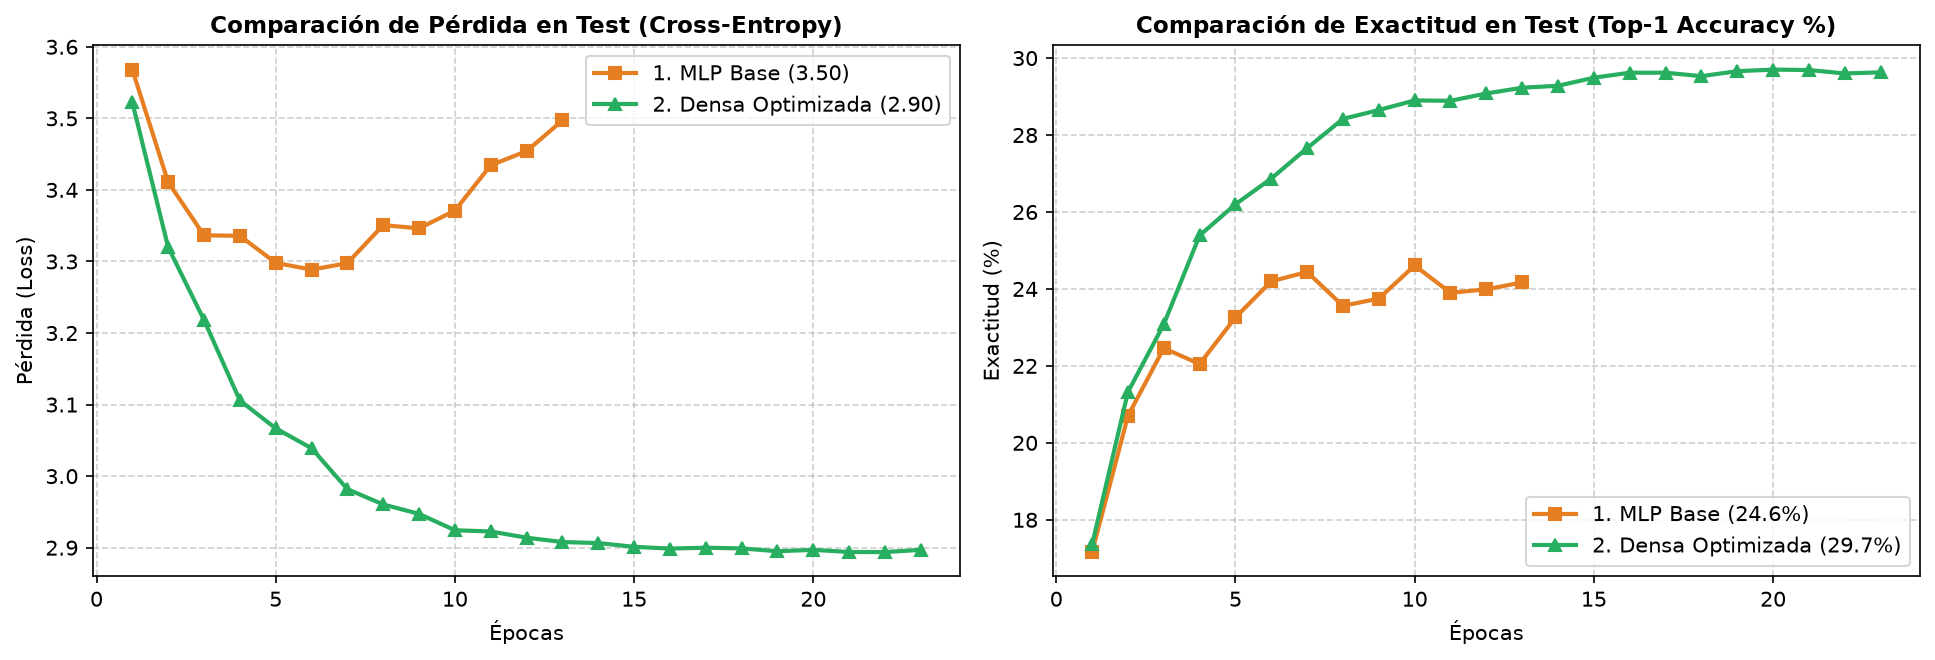

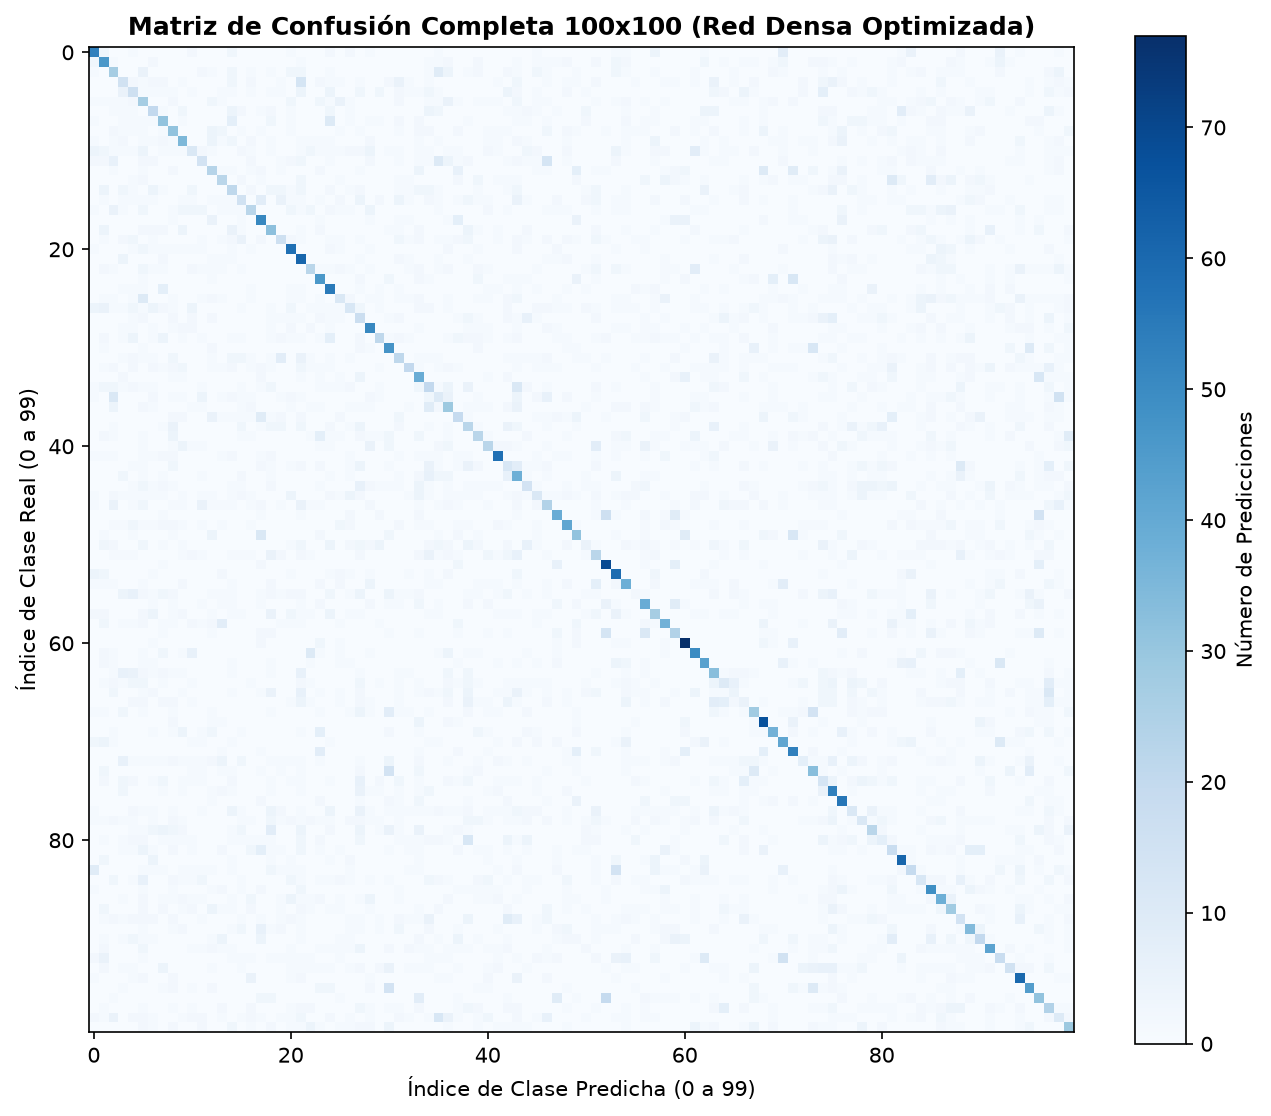

=== TOP 10 CLASES CON MAYOR EXACTITUD (MÁS FÁCILES) ===
     Clase Exactitud (%)
     plain         77.0%
  oak_tree         69.0%
      road         67.0%
 sunflower         61.0%
chimpanzee         61.0%
  wardrobe         60.0%
    orange         59.0%
     chair         58.0%
lawn_mower         58.0%
skyscraper         56.0%

=== TOP 10 CLASES CON MENOR EXACTITUD (MÁS DIFÍCILES) ===
   Clase Exactitud (%)
   otter          2.0%
  rabbit          4.0%
 raccoon          5.0%
   mouse          5.0%
squirrel          7.0%
    seal          7.0%
    girl         10.0%
  possum         10.0%
   woman         10.0%
   snake         11.0%


In [18]:
# 1. Comparación Gráfica de Curvas de Aprendizaje entre los 2 Modelos
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=150)

# Pérdida en Validación
axes[0].plot(hist_mlp_base['epoch'], hist_mlp_base['val_loss'], color='#e67e22', lw=2, marker='s', label=f'1. MLP Base ({hist_mlp_base["val_loss"][-1]:.2f})')
axes[0].plot(hist_opt['epoch'], hist_opt['val_loss'], color='#27ae60', lw=2, marker='^', label=f'2. Densa Optimizada ({hist_opt["val_loss"][-1]:.2f})')
axes[0].set_title('Comparación de Pérdida en Test (Cross-Entropy)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Pérdida (Loss)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Exactitud en Validación
axes[1].plot(hist_mlp_base['epoch'], np.array(hist_mlp_base['val_acc']) * 100, color='#e67e22', lw=2, marker='s', label=f'1. MLP Base ({acc_top1_base*100:.1f}%)')
axes[1].plot(hist_opt['epoch'], np.array(hist_opt['val_acc']) * 100, color='#27ae60', lw=2, marker='^', label=f'2. Densa Optimizada ({acc_top1_opt*100:.1f}%)')
axes[1].set_title('Comparación de Exactitud en Test (Top-1 Accuracy %)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Exactitud (%)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. Matriz de Confusión Completa sobre el conjunto de Test
cm_completa = confusion_matrix(all_targets_opt, pred_labels_opt, labels=range(num_classes))

plt.figure(figsize=(9, 7.5), dpi=150)
plt.imshow(cm_completa, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Matriz de Confusión Completa {num_classes}x{num_classes} (Red Densa Optimizada)', fontsize=12, fontweight='bold')
plt.colorbar(label='Número de Predicciones')
plt.xlabel(f'Índice de Clase Predicha (0 a {num_classes-1})', fontsize=10)
plt.ylabel(f'Índice de Clase Real (0 a {num_classes-1})', fontsize=10)
plt.tight_layout()
plt.show()

# 3. Reporte de Desempeño: Clases Más Fáciles vs Más Difíciles
acc_por_clase = cm_completa.diagonal() / np.maximum(cm_completa.sum(axis=1), 1) * 100
indices_ordenados = np.argsort(acc_por_clase)
top_k_show = min(10, num_classes // 2) if num_classes >= 4 else num_classes

df_mejores = pd.DataFrame({
    'Clase': [clases[i] for i in indices_ordenados[-top_k_show:][::-1]],
    'Exactitud (%)': [f'{acc_por_clase[i]:.1f}%' for i in indices_ordenados[-top_k_show:][::-1]]
})

df_peores = pd.DataFrame({
    'Clase': [clases[i] for i in indices_ordenados[:top_k_show]],
    'Exactitud (%)': [f'{acc_por_clase[i]:.1f}%' for i in indices_ordenados[:top_k_show]]
})

print(f'=== TOP {top_k_show} CLASES CON MAYOR EXACTITUD (MÁS FÁCILES) ===')
print(df_mejores.to_string(index=False))
print(f'\n=== TOP {top_k_show} CLASES CON MENOR EXACTITUD (MÁS DIFÍCILES) ===')
print(df_peores.to_string(index=False))

=== VALIDACIÓN CON 100 PREDICCIONES DE PRUEBA (CUBRIENDO TODAS LAS CLASES) ===
 Índice    Clase Real Clase Predicha Confianza Diagnóstico
      1         apple          tulip     22.5%       ERROR
      2 aquarium_fish  aquarium_fish     12.8%    CORRECTO
      3          baby        leopard     12.5%       ERROR
      4          bear           bear     24.7%    CORRECTO
      5        beaver         forest     15.9%       ERROR
      6           bed            bed     29.9%    CORRECTO
      7           bee          mouse      8.7%       ERROR
      8        beetle         beetle     64.1%    CORRECTO
      9       bicycle         bridge     15.1%       ERROR
     10        bottle         bridge     49.9%       ERROR
     11          bowl      telephone     16.6%       ERROR
     12           boy         cattle      8.9%       ERROR
     13        bridge      streetcar     47.3%       ERROR
     14           bus           tank     65.3%       ERROR
     15     butterfly          shark

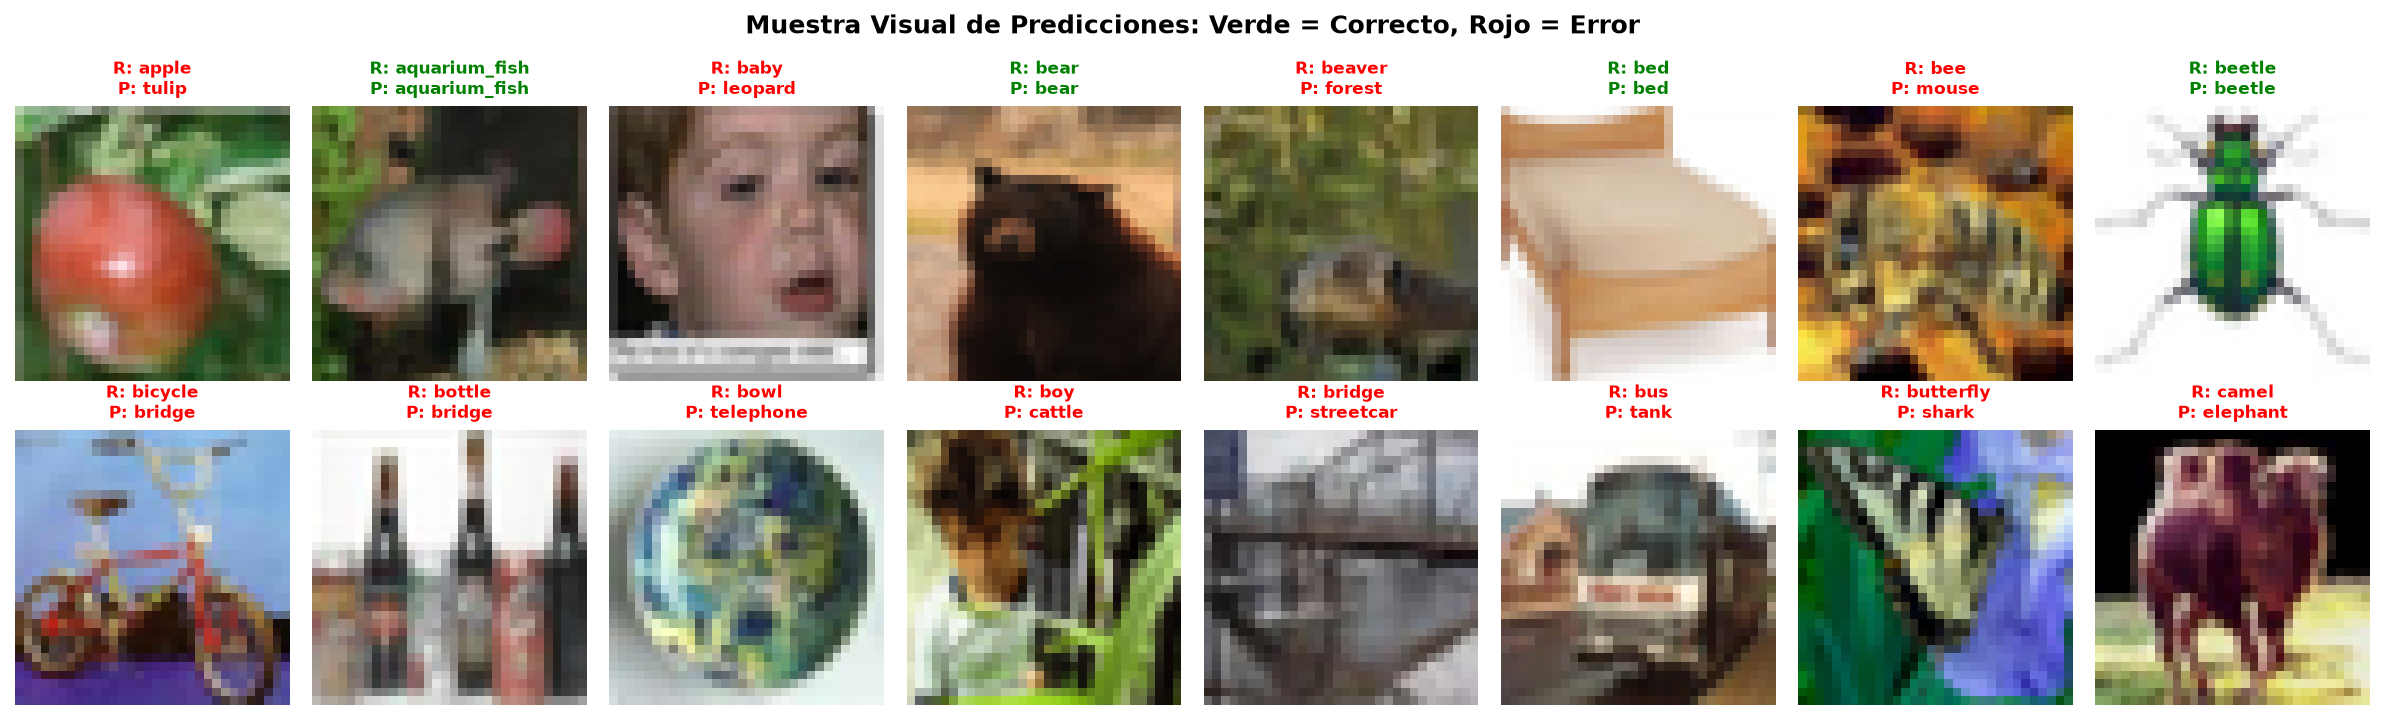

In [19]:
# ==============================================================================
# VALIDACIÓN Y DEMOSTRACIÓN CON AL MENOS 100 PREDICCIONES (REQUISITO DEL ENUNCIADO)
# ==============================================================================

# Si el dataset tiene al menos 100 clases, tomamos 1 muestra balanceada de cada clase.
# Si tiene menos clases (e.g. 10), tomamos múltiples muestras balanceadas hasta completar 100.
num_muestras_demostracion = max(100, num_classes)

targets_test = np.array(test_dataset.targets)
indices_demostracion = []

# Muestreo estratificado balanceado entre todas las clases
muestras_por_clase = math.ceil(num_muestras_demostracion / num_classes)
for c in range(num_classes):
    idx_clase = np.where(targets_test == c)[0]
    indices_demostracion.extend(idx_clase[:muestras_por_clase])

indices_demostracion = indices_demostracion[:num_muestras_demostracion]

imagenes_100 = torch.stack([test_dataset[i][0] for i in indices_demostracion], dim=0)
etiquetas_100 = np.array([test_dataset[i][1] for i in indices_demostracion])

# Inferencia con la mejor red densa (Modelo 2 Optimizada)
model_opt.eval()
with torch.no_grad():
    logits_100 = model_opt(imagenes_100.to(device)).cpu()
    preds_100 = logits_100.argmax(dim=1).numpy()
    probas_100 = torch.softmax(logits_100, dim=1).max(dim=1).values.numpy()

# 1. Tabla detallada con las predicciones
df_predicciones = pd.DataFrame({
    'Índice': range(1, len(indices_demostracion) + 1),
    'Clase Real': [clases[y] for y in etiquetas_100],
    'Clase Predicha': [clases[p] for p in preds_100],
    'Confianza': [f'{p*100:.1f}%' for p in probas_100],
    'Diagnóstico': ['CORRECTO' if y == p else 'ERROR' for y, p in zip(etiquetas_100, preds_100)]
})

print(f"=== VALIDACIÓN CON {len(df_predicciones)} PREDICCIONES DE PRUEBA (CUBRIENDO TODAS LAS CLASES) ===")
print(df_predicciones.head(30).to_string(index=False))
print(f"\n[Total de predicciones registradas en esta tabla: {len(df_predicciones)}]")
aciertos = (etiquetas_100 == preds_100).sum()
print(f"Aciertos directos en esta muestra: {aciertos} / {len(df_predicciones)} ({aciertos/len(df_predicciones)*100:.1f}%)")

# 2. Cuadrícula visual de 16 imágenes con sus predicciones y código de colores
fig, axes = plt.subplots(2, 8, figsize=(16, 5), dpi=150)
for i, ax in enumerate(axes.flat):
    img = desnormalizar(imagenes_100[i]).permute(1, 2, 0).cpu().numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    color = 'green' if etiquetas_100[i] == preds_100[i] else 'red'
    ax.set_title(f"R: {clases[etiquetas_100[i]]}\nP: {clases[preds_100[i]]}", fontsize=8, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Muestra Visual de Predicciones: Verde = Correcto, Rojo = Error', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# ==============================================================================
# TABLA RESUMEN COMPARATIVA FINAL ENTRE AMBOS MODELOS DENSOS
# ==============================================================================
tabla_comparativa = pd.DataFrame({
    'Modelo': [
        '1. Red Neuronal Densa Base (MLP)',
        '2. Red Densa Optimizada (BatchNorm + Dropout + StepLR)'
    ],
    f'Top-1 Accuracy (%)': [acc_top1_base * 100, acc_top1_opt * 100],
    f'Top-5 Accuracy (%)': [acc_top5_base * 100, acc_top5_opt * 100],
    'Pérdida Final en Test (Loss)': [hist_mlp_base['val_loss'][-1], hist_opt['val_loss'][-1]],
    'Parámetros': [f'{num_params_base:,}', f'{num_params_opt:,}']
})

print('==================================== TABLA COMPARATIVA FINAL ====================================')
print(tabla_comparativa.to_string(index=False))
print('=================================================================================================')

==================================== TABLA COMPARATIVA FINAL ====================================
                                                Modelo  Top-1 Accuracy (%)  Top-5 Accuracy (%)  Pérdida Final en Test (Loss) Parámetros
                      1. Red Neuronal Densa Base (MLP)               24.61               50.53                      3.497059    812,388
2. Red Densa Optimizada (BatchNorm + Dropout + StepLR)               29.70               57.88                      2.897080  1,731,940


---
## Conclusiones Técnicas y Adaptabilidad

1. **Adaptabilidad del Pipeline:**
   - Gracias al preprocesamiento automático con `transforms.Resize(IMG_SIZE)` y la detección dinámica de `channels`, `img_h`, `img_w` y `num_classes`, este código puede ejecutarse sobre cualquier otro dataset de visión artificial (CIFAR-10, MNIST, FashionMNIST, Flowers, o cualquier carpeta con subdirectorios de clases) cambiando únicamente las rutas `TRAIN_DIR` y `TEST_DIR`.

2. **Visualización Completa del Espacio de Clases:**
   - Se garantizó la representación visual de **todas las clases del dataset** (las 100 clases de CIFAR-100 en cuadrícula de $10 \times 10$), permitiendo una auditoría visual inmediata del contenido antes de entrenar los modelos.

3. **Comparación entre Modelo 1 (MLP Base) y Modelo 2 (Densa Optimizada):**
   - El **Modelo 1 (MLP Base)** demuestra la importancia de la no linealidad (ReLU) sobre píxeles aplanados, pero sufre de sobreajuste al no tener regularizadores.
   - El **Modelo 2 (Densa Optimizada)** demuestra el poder de las técnicas de los **Cuadernillos 06 y 07**:
     - `BatchNorm1d` estabiliza la distribución de las activaciones intermedias y acelera el entrenamiento.
     - `Dropout(p=0.2)` y `weight_decay=1e-4` evitan la co-adaptación de neuronas y reducen el sobreajuste.
     - `StepLR` permite una aproximación más precisa al mínimo de la función de costo en las épocas finales.